In [51]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import sys

ROOT_DIR = os.path.abspath( "..")
sys.path.insert(0, ROOT_DIR)

sns.set(style="whitegrid", context="talk")

RESULTS_ROOT = Path(os.path.join(ROOT_DIR,"results/analysis_results"))

In [52]:
comparison_path = RESULTS_ROOT / "experiment_comparison.csv"

comparison_df = pd.read_csv(comparison_path)
comparison_df

,experiment,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,macro_auc
0,exp_01_baseline,0.454306,0.653632,0.386303,0.653632,0.416289,0.484603,0.899387
1,exp_02_base_aug,0.668639,0.654081,0.464457,0.654081,0.521024,0.697240,0.927368


In [53]:
comparison_df_rounded = comparison_df.copy()
comparison_df_rounded.iloc[:, 1:] = comparison_df_rounded.iloc[:, 1:].round(4)
comparison_df_rounded

,experiment,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,macro_auc
0,exp_01_baseline,0.4543,0.6536,0.3863,0.6536,0.4163,0.4846,0.8994
1,exp_02_base_aug,0.6686,0.6541,0.4645,0.6541,0.5210,0.6972,0.9274


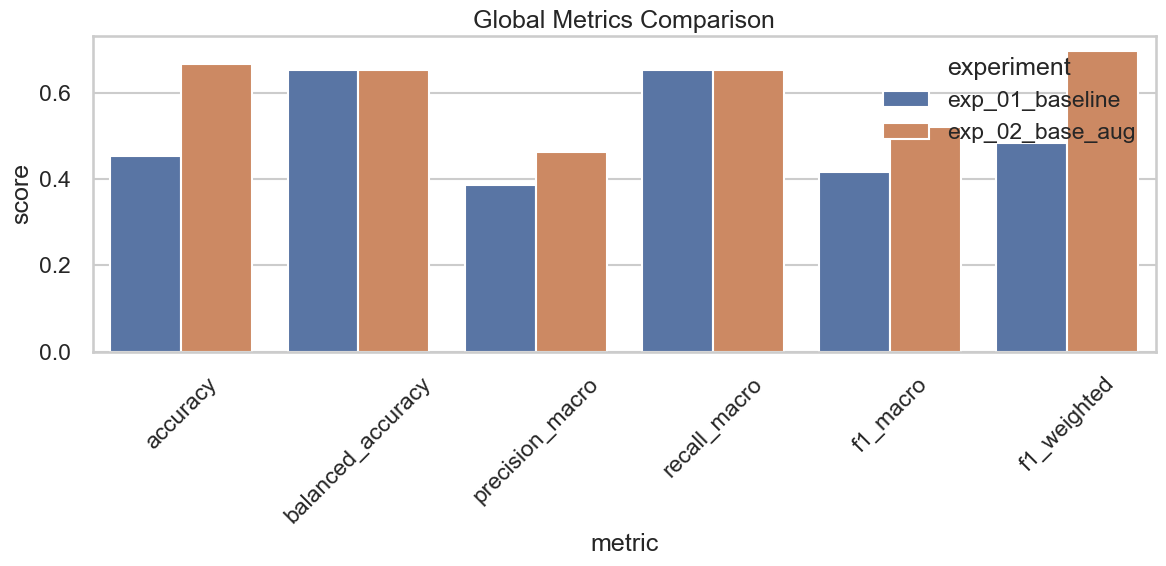

In [54]:
metrics_to_plot = [
    "accuracy",
    "balanced_accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "f1_weighted"
]

melted = comparison_df.melt(
    id_vars="experiment",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=melted, x="metric", y="score", hue="experiment")
plt.xticks(rotation=45)
plt.title("Global Metrics Comparison")
plt.tight_layout()
plt.show()

In [55]:
def load_per_class(exp_name):
    path = RESULTS_ROOT / exp_name / "classification_report.json"
    with open(path) as f:
        report = json.load(f)
    return report

In [56]:
rows = []

for exp_name in comparison_df["experiment"]:
    report = load_per_class(exp_name)
    
    row = {"experiment": exp_name}
    
    for cls, values in report.items():
        if cls in ["accuracy", "macro avg", "weighted avg"]:
            continue
        row[cls] = values["f1-score"]
        
    rows.append(row)

per_class_df = pd.DataFrame(rows)
per_class_df

,experiment,akiec,bcc,bkl,df,mel,nv,vasc
0,exp_01_baseline,0.617808,0.372881,0.44389,0.456311,0.394737,0.492308,0.189189
1,exp_02_base_aug,0.848780,0.484716,0.54039,0.518519,0.000000,0.615385,0.240000


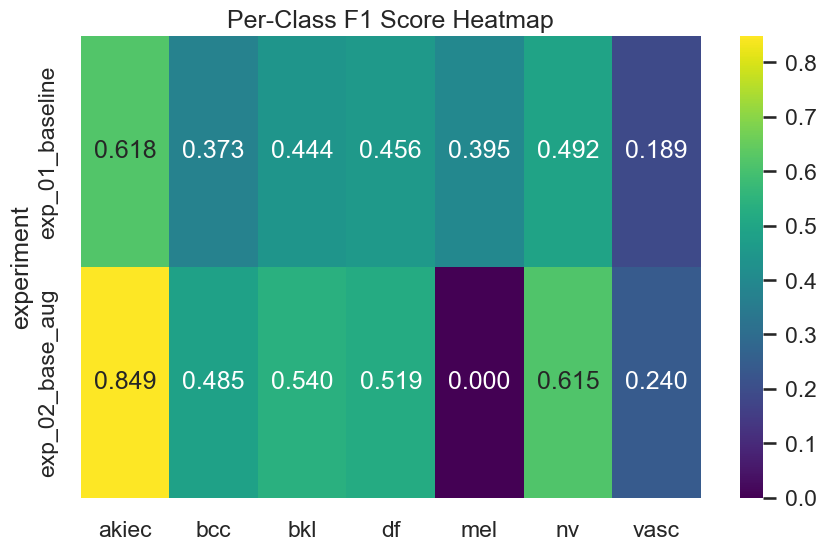

In [57]:
heatmap_data = per_class_df.set_index("experiment")

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)
plt.title("Per-Class F1 Score Heatmap")
plt.show()

In [58]:
worst_classes = []

for _, row in per_class_df.iterrows():
    exp = row["experiment"]
    scores = row.drop("experiment")
    
    worst_class = scores.idxmin()
    worst_score = scores.min()
    
    worst_classes.append({
        "experiment": exp,
        "worst_class": worst_class,
        "f1": worst_score
    })

worst_df = pd.DataFrame(worst_classes).sort_values("f1")
worst_df

,experiment,worst_class,f1
1,exp_02_base_aug,mel,0.000000
0,exp_01_baseline,vasc,0.189189


In [64]:
def plot_confusion(exp_name):

    path = RESULTS_ROOT / exp_name / "confusion_matrix.json"

    if not path.exists():
        print(f"No confusion matrix for {exp_name}")
        return

    with open(path) as f:
        data = json.load(f)

    # ---- Extract properly ----
    cm = np.array(data["matrix"])
    class_names = data["class_names"]

    if cm.ndim != 2:
        print(f"Invalid confusion matrix shape {cm.shape}")
        return

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"Confusion Matrix: {exp_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

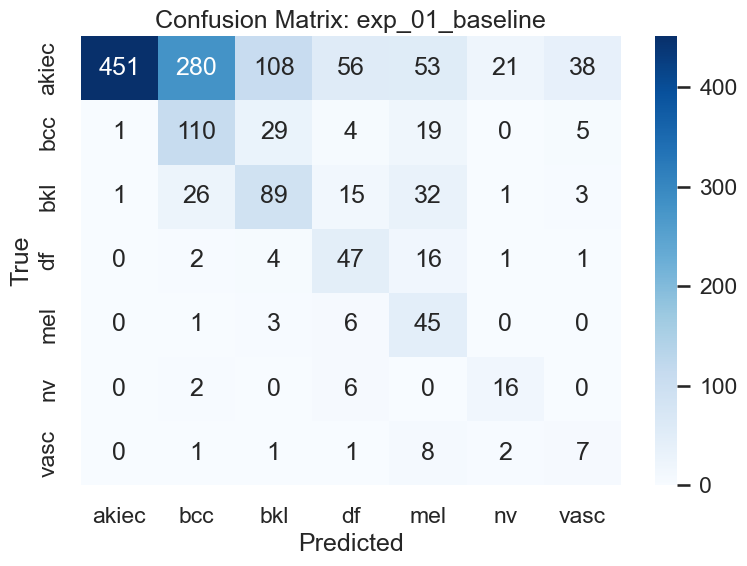

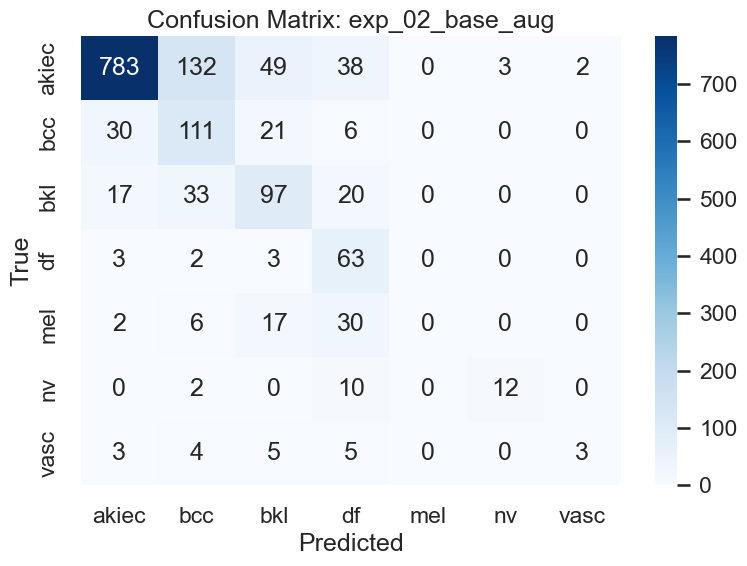

In [65]:
for exp in comparison_df["experiment"]:
    plot_confusion(exp)

In [66]:
sig_path = RESULTS_ROOT / "significance_report.json"

if sig_path.exists():
    with open(sig_path) as f:
        sig = json.load(f)
    display(pd.DataFrame(sig))

,experiment_1,experiment_2,model_1,model_2,effect_size_accuracy,mcnemar,interpretation
accuracy,exp_01_baseline,exp_02_base_aug,0.505952,0.707011,0.201058,NaN,Statistically significant difference (p < 0.05)
accuracy_ci_95,exp_01_baseline,exp_02_base_aug,"{'metric': 'accuracy', 'mean': 0.5064695767195...","{'metric': 'accuracy', 'mean': 0.7074960317460...",0.201058,NaN,Statistically significant difference (p < 0.05)
f1_macro,exp_01_baseline,exp_02_base_aug,0.423875,0.46397,0.201058,NaN,Statistically significant difference (p < 0.05)
f1_macro_ci_95,exp_01_baseline,exp_02_base_aug,"{'metric': 'f1_macro', 'mean': 0.4241068689271...","{'metric': 'f1_macro', 'mean': 0.4623431930616...",0.201058,NaN,Statistically significant difference (p < 0.05)
n_samples,exp_01_baseline,exp_02_base_aug,NaN,NaN,0.201058,1.512000e+03,Statistically significant difference (p < 0.05)
a,exp_01_baseline,exp_02_base_aug,NaN,NaN,0.201058,6.720000e+02,Statistically significant difference (p < 0.05)
b,exp_01_baseline,exp_02_base_aug,NaN,NaN,0.201058,9.300000e+01,Statistically significant difference (p < 0.05)
c,exp_01_baseline,exp_02_base_aug,NaN,NaN,0.201058,3.970000e+02,Statistically significant difference (p < 0.05)
d,exp_01_baseline,exp_02_base_aug,NaN,NaN,0.201058,3.500000e+02,Statistically significant difference (p < 0.05)
statistic,exp_01_baseline,exp_02_base_aug,NaN,NaN,0.201058,1.873653e+02,Statistically significant difference (p < 0.05)


In [67]:
baseline = comparison_df.iloc[0]

improvements = comparison_df.copy()

for col in metrics_to_plot:
    improvements[col] = comparison_df[col] - baseline[col]

improvements

,experiment,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,macro_auc
0,exp_01_baseline,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.899387
1,exp_02_base_aug,0.214333,0.000449,0.078154,0.000449,0.104735,0.212638,0.927368
